In [1]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
from misc import *
try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

from inference import  prepare_true_waveform

startup


# GENERAL RESULTS FOR EMRI CASE:

EMRI PARARMS: theta0: [1000000.0, 10.0, 0.9, 7.5, 0.5, 0.7853981633974483, 1.0, 0.9, 0.4]
SNR : **56.117062890601325**

## 1 PA best fit points : 
	
	initial_overlap (at True point): 56.11987144384806
	overlap for biased best fit point: 56.17532586348347
	final_overlap: 56.18002756796321 
	x: [999946.0152291667, 9.999519502525063, 0.8999722828661775, 7.500180664516796, 0.5000138337896617, 0.7852559788367258, 1.0129022856696843, 1.0763850352976, 0.38346661248402214]

read log files for recent two runs ig

## 0 PA best fit (BF) points 
	
	initial_overlap (at True Points): 34.7905807899
	Overlap of the best point: 56.18183483743688
	Best point : [1000117.0084713349, 10.000740815309555, 0.9000818991095976, 7.499523107439233, 0.4999842634784489, 0.7813479093106849, 1.010937509252813, 1.0770059384260007, 0.3820490832884277, 7.785395975446039e-07, 5.944319035025486e-07]


## Simple Deviation Term (from 0pa point)

	intial overlap will be same as 0pa best fit case
	final overlap: 56.182946240232894
	x_best_fit = [1000008.8232475417, 9.999571552108547, 0.9000238821231858, 7.499888382688533, 0.500008994502528, 0.7807665326272081, 1.0127748551659106, 1.092204513244811, 0.3880586212252709, 2.4076903823412796, -2.5709170953033844]

[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 3155814) PSD_funcs: (3, 1577907)
[TRUE] SNR: 184.186765
[TRUE] SNR - Channel 0: 28.590175
[TRUE] SNR - Channel 1: 24.933803
[TRUE] SNR - Channel 2: 180.237820
[INFO] Frequency resolution delta_f: 3.168755e-08 Hz, Number of frequency bins: 1577908
freq_max: 0.050000 Hz and Freq_min: 0.000000 Hz


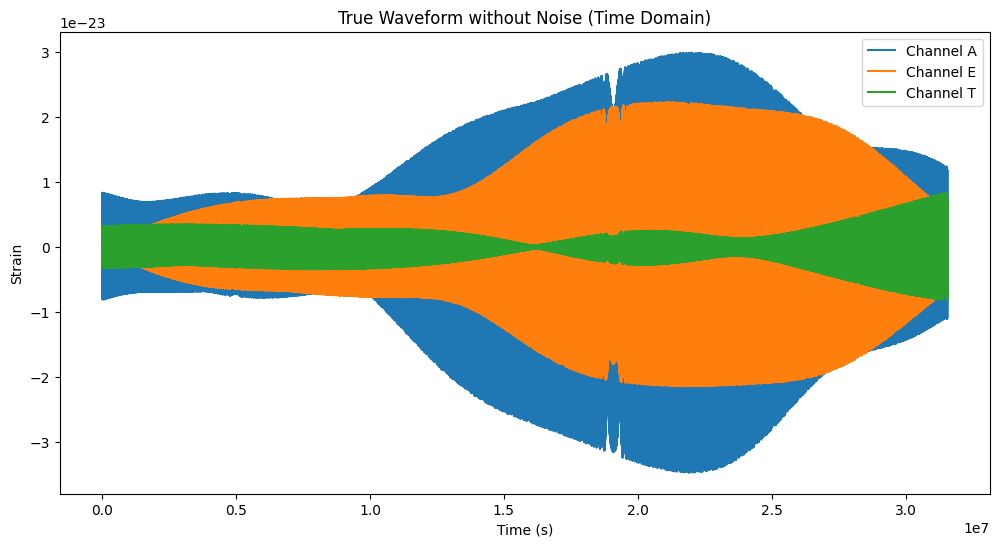

[INFO] Added noise to true waveform FFT

shape of waveform_true_fft after noise addition: (3, 1577907)


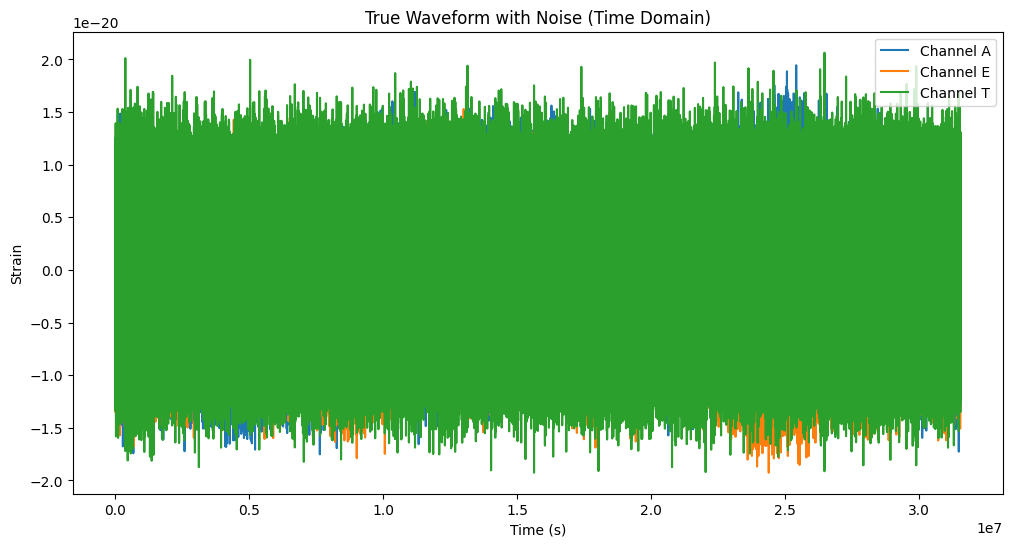

Length of PSD: 1577907


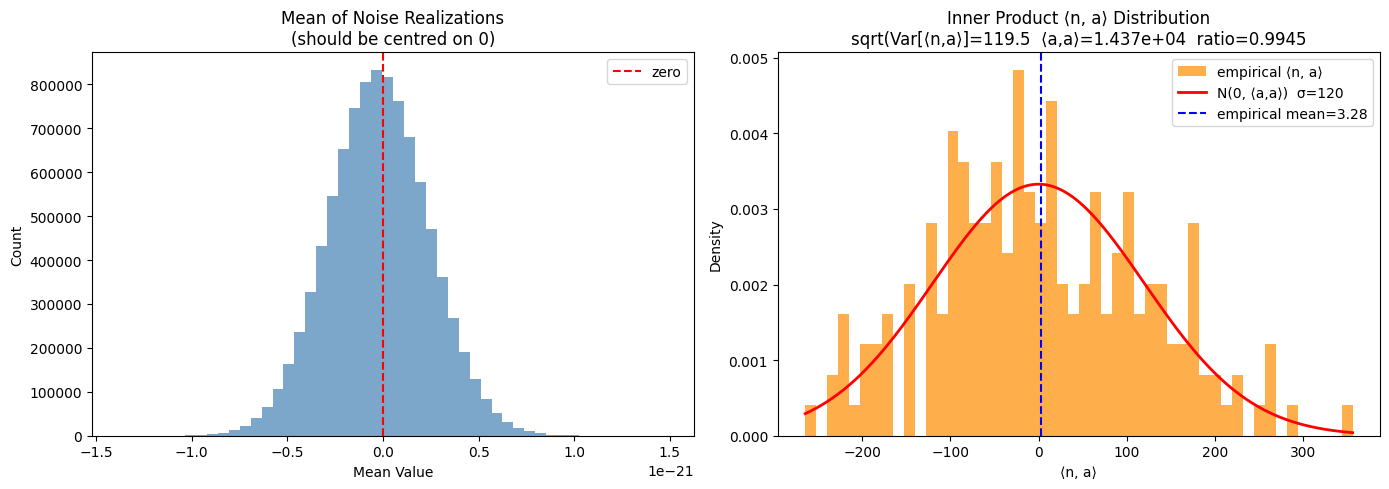

  Noise model consistency check
  Backend                : CuPy (GPU)
  Realizations           : 200
  N time samples         : 3155812  |  PSD bins passed: 1577906
  N (template samples)   : 3155814  →  aligned to 3155812
  Max |mean noise|       : 1.4832e-21  (expect ≈ 0)
  E[⟨n, a⟩]             : 3.2804e+00           (expect ≈ 0)
  Var[⟨n, a⟩]           : 14287.8
  ⟨a, a⟩                : 14367.1
  Ratio Var/⟨a,a⟩       : 0.994484          (expect ≈ 1.0)
Noise consistency check results: {'mean_noise': array([[-3.08572637e-22,  5.21234944e-22, -3.09194809e-22, ...,
        -2.71103137e-22,  2.98321182e-22,  2.02109510e-22],
       [ 5.50421568e-23, -1.07322797e-22,  3.25350610e-22, ...,
        -2.30612469e-22,  2.31649956e-22,  2.19601881e-22],
       [-3.24760315e-22,  9.12728428e-23,  3.47851399e-23, ...,
        -2.56312609e-22, -3.72123314e-22,  5.36292394e-22]],
      shape=(3, 3155812)), 'inner_products': array([ 202.77357066, -194.17222559,  -52.51708988, -173.73790148,
     

{'m1': np.float64(1000000.0),
 'm2': np.float64(10.0),
 'a': np.float64(0.9),
 'p0': np.float64(7.5),
 'e0': np.float64(0.5),
 'Y0': np.float64(1.0),
 'dist': np.float64(5.0),
 'qS': np.float64(0.7853981633974483),
 'phiS': np.float64(1.0),
 'qK': np.float64(1.0),
 'phiK': np.float64(1.0471975511965976),
 'Phi_phi0': np.float64(0.9),
 'Phi_theta0': np.float64(0.5),
 'Phi_r0': np.float64(0.4),
 'dt': 10,
 'T': 1.0,
 'chi2': 0.0,
 'dev_1': 0.0,
 'dev_2': 0.0,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x1554c8103410>,
 'PSD_funcs': array([[6.81763434e-35, 1.70440862e-35, 7.57514968e-36, ...,
         1.61311193e-40, 1.61310358e-40, 1.61309523e-40],
        [6.81763434e-35, 1.70440862e-35, 7.57514968e-36, ...,
         1.61311193e-40, 1.61310358e-40, 1.61309523e-40],
        [2.65994853e-56, 1.06395802e-55, 2.39388950e-55, ...,
         5.36070468e-40, 5.36068302e-40, 5.36066135e-40]],
       shape=(3, 1577907)),
 'waveform_true_fft': array([[-6.25689796e-15-2.560

In [2]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1e6,1e1,0.9, 7.5,  5.00000000e-01,  1.00000000e+00,
          5.0,  np.pi/4,  1.0, 1,  np.pi/3,  9.00000000e-01, 5.00000000e-01,  4.00000000e-01])

signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
signal_param_array = np.array(list(signal_param.values()))
dt = 10  #Time step for waveform generation; default 0.1s
T= 1.0

chi2 = 0.0 
dev_1 = 0.0
dev_2 = 0.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=True, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx['waveform_true_fft_without_noise'], ctx['waveform_true_fft_without_noise'], ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
ctx

# Overlap with Noise and With True Signal Without Noise

In [3]:
noise_f =  ctx['noise']
Respsone = ctx['waveform_response']


In [4]:
signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
])

## 1PA best fit

Best fit parameters for 1PA: [999946.0152291667, 9.999519502525063, 0.8999722828661775, 7.500180664516796, 0.5000138337896617, 0.7852559788367258, 1.0129022856696843, 1.0763850352976, 0.38346661248402214]


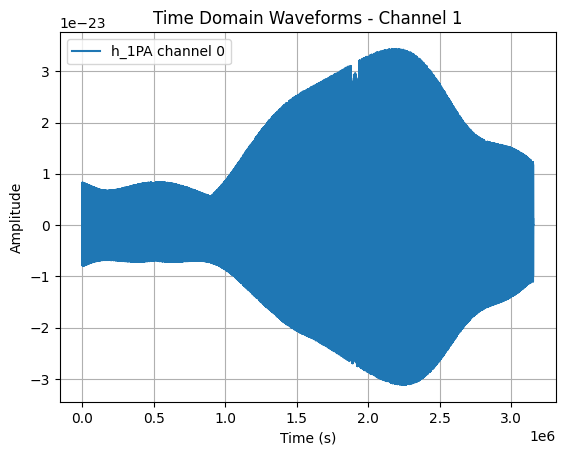

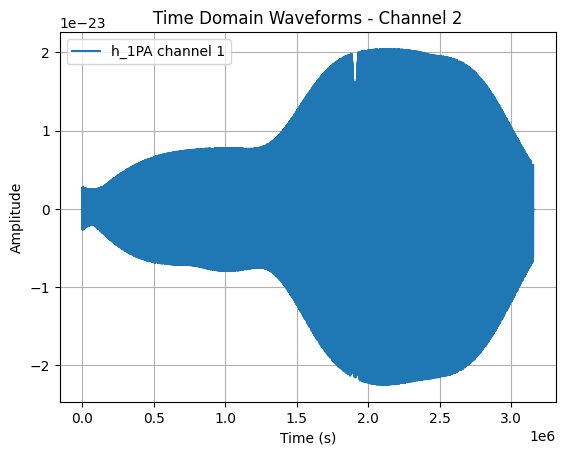

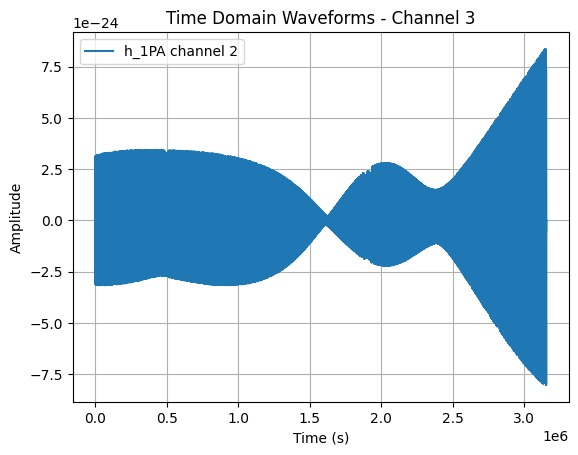

noise inner product with 1PA: -167.7304725908366
detection SNR for noise: -0.899226414387945
Actual overlap: 185.34778331100836
detection SNR using true waveform: 184.17550858412255
detection SNR using actual signal: 183.2762821697346


In [5]:
x_best_fit_1PA =  [999946.0152291667, 9.999519502525063, 0.8999722828661775, 7.500180664516796, 0.5000138337896617,
                    0.7852559788367258, 1.0129022856696843, 1.0763850352976, 0.38346661248402214]
# x_best_fit_1PA =  true_params
print("Best fit parameters for 1PA:", x_best_fit_1PA)
add_kwargs = {'chi2': 0,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': 0, 'dev_2': 0}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_1PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs['chi2'],add_kwargs['evolve_1PA'],add_kwargs['evolve_primary'],
                    add_kwargs['evolve_2PA'], add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2']]
emri_kwargs =  {"T": ctx['T'], "dt": ctx['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}
h_1PA = xp.array(Respsone(*wave_params, **emri_kwargs))
for i in range(3):
    plt.plot(h_1PA[i].get(), label=f"h_1PA channel {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Time Domain Waveforms - Channel {i+1}")
    plt.legend()
    plt.grid()
    plt.show()
h_1PA_f = compute_fft_with_windowing(h_1PA, ctx['dt'], ctx['N_fiducial'],type=None,use_gpu=True,n_channels=3)
n_hf = inner_prod(h_1PA_f, noise_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("noise inner product with 1PA:", n_hf)
optimal_snr_h_1PA = inner_prod(h_1PA_f, h_1PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp
                               )
print("detection SNR for noise:", n_hf/np.sqrt(optimal_snr_h_1PA))

actual_overlap = inner_prod(ctx['waveform_true_fft_without_noise'], h_1PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_1PA))
print("detection SNR using actual signal:", actual_overlap/np.sqrt(optimal_snr_h_1PA)  + n_hf/np.sqrt(optimal_snr_h_1PA))

## 0PA best fit

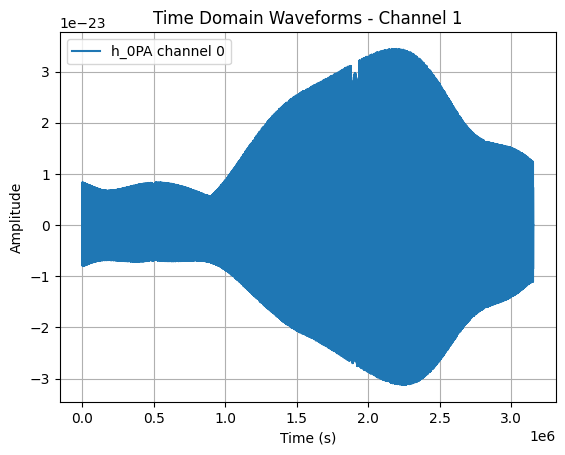

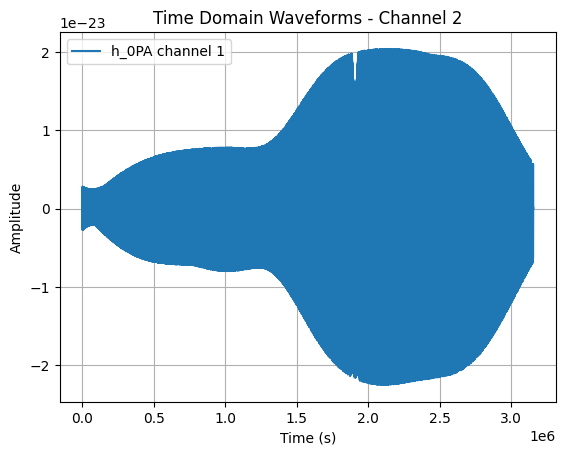

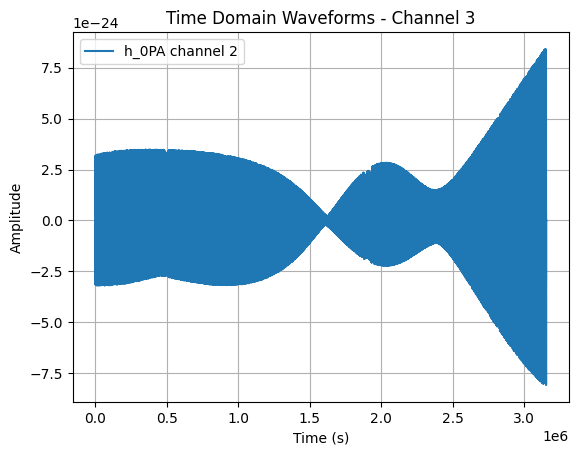

noise inner product with 0PA: -167.21265532233673
detection SNR -0.8995153331417204
Actual overlap: 185.0321127460393
detection SNR using true waveform: 184.17625705884237
detection SNR using actual signal: 183.27674172570065


In [6]:
x_best_fit_0PA =  [1000117.1746453623, 10.000746537405398, 0.9000818185010706, 7.499523528259836, 0.49998409810055455, 0.781083551558284, 1.0107113878780554, 1.074751977593931, 0.38365434296900686]
add_kwargs = {'chi2': 0,'evolve_1PA': False,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': 0, 'dev_2': 0}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_0PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs['chi2'],add_kwargs['evolve_1PA'],add_kwargs['evolve_primary'],
                    add_kwargs['evolve_2PA'], add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2']]

emri_kwargs =  {"T": ctx['T'], "dt": ctx['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}

h_0PA = xp.array(Respsone(*wave_params, **emri_kwargs))
for i in range(3):
    plt.plot(h_0PA[i].get(), label=f"h_0PA channel {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Time Domain Waveforms - Channel {i+1}")
    plt.legend()
    plt.grid()
    plt.show()
h_0PA_f = compute_fft_with_windowing(h_0PA, ctx['dt'], ctx['N_fiducial'],type=None,use_gpu=True,n_channels=3)
n_hf = inner_prod(h_0PA_f, noise_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("noise inner product with 0PA:", n_hf)
optimal_snr_h_0PA = inner_prod(h_0PA_f, h_0PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp
                               )
print("detection SNR", n_hf/np.sqrt(optimal_snr_h_0PA))

actual_overlap = inner_prod(ctx['waveform_true_fft_without_noise'], h_0PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_0PA))
print("detection SNR using actual signal:", actual_overlap/np.sqrt(optimal_snr_h_0PA)  + n_hf/np.sqrt(optimal_snr_h_0PA))

## 0PA best fit + deviation

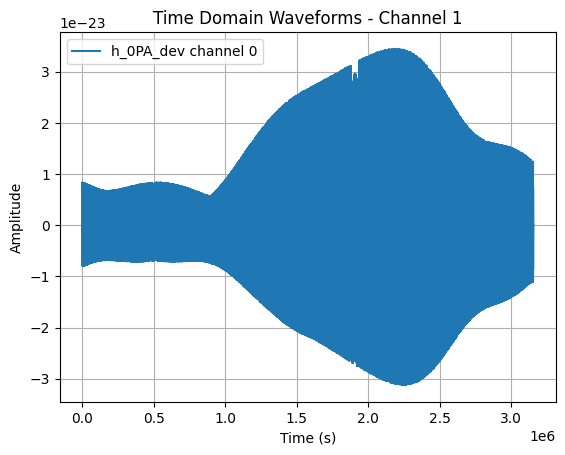

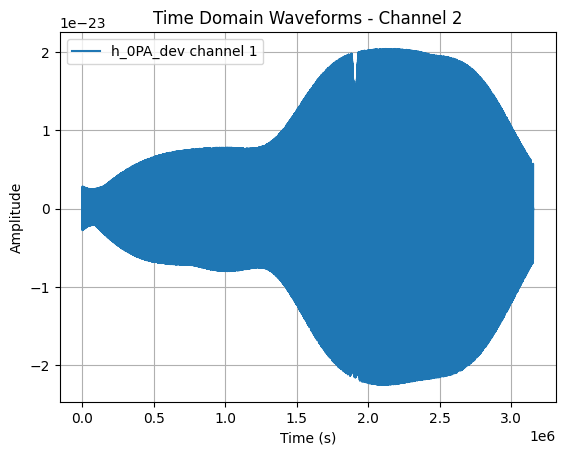

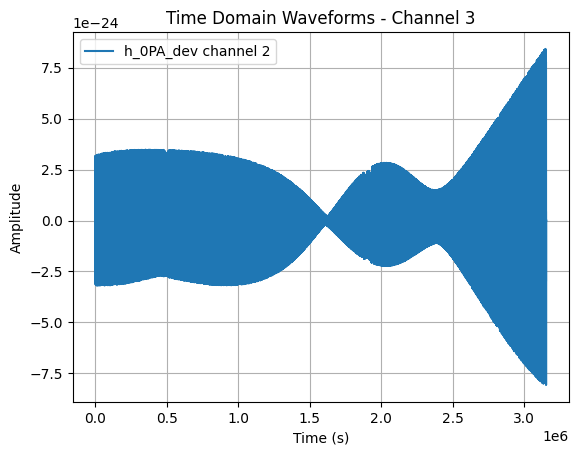

noise inner product with 0PA: -166.87628620701807
detection SNR -0.8974095546076237
Actual overlap: 185.06226391988378
detection SNR using true waveform: 184.17547748478694
detection SNR using actual signal: 183.2780679301793


In [7]:
x_best_fit_0PA_dev =  [1000008.8232475417, 9.999571552108547, 0.9000238821231858, 7.499888382688533, 0.500008994502528, 0.7807665326272081, 1.0127748551659106,
 1.092204513244811, 0.3880586212252709, 2.4076903823412796, -2.5709170953033844]

add_kwargs = {'chi2': 0,'evolve_1PA': False,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': x_best_fit_0PA_dev[-2], 'dev_2': x_best_fit_0PA_dev[-1]}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = x_best_fit_0PA_dev

wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs['chi2'],add_kwargs['evolve_1PA'],add_kwargs['evolve_primary'],
                    add_kwargs['evolve_2PA'], add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2']]

emri_kwargs =  {"T": ctx['T'], "dt": ctx['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}

h_0PA_dev = xp.array(Respsone(*wave_params, **emri_kwargs))
for i in range(3):
    plt.plot(h_0PA_dev[i].get(), label=f"h_0PA_dev channel {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Time Domain Waveforms - Channel {i+1}")
    plt.legend()
    plt.grid()
    plt.show()
h_0PA_dev_f = compute_fft_with_windowing(h_0PA_dev, ctx['dt'], ctx['N_fiducial'],type=None,use_gpu=True,n_channels=3)
n_hf_dev = inner_prod(h_0PA_dev_f, noise_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("noise inner product with 0PA:", n_hf_dev)
optimal_snr_h_0PA_dev = inner_prod(h_0PA_dev_f, h_0PA_dev_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp
                               )
print("detection SNR", n_hf_dev/np.sqrt(optimal_snr_h_0PA_dev))

actual_overlap = inner_prod(ctx['waveform_true_fft_without_noise'], h_0PA_dev_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_0PA_dev))
print("detection SNR using actual signal:", actual_overlap/np.sqrt(optimal_snr_h_0PA_dev)  + n_hf_dev/np.sqrt(optimal_snr_h_0PA_dev))

## Marginals

In [ ]:
from matplotlib.gridspec import GridSpec

# ── Parameter setup ────────────────────────────────────────────────────────────
param_names_label = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
    r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$']

x_best_fit_1PA = [999946.0152291667, 9.999519502525063, 0.8999722828661775, 7.500180664516796, 
                  0.5000138337896617, 0.7852559788367258, 1.0129022856696843, 1.0763850352976, 0.38346661248402214]


fisher_bounds = [(np.float64(999756.3234223108), np.float64(1000133.8589748443)),
                  (np.float64(9.998248676787117), np.float64(10.000788364051246)),
                    (np.float64(0.8998553909779333), np.float64(0.9000877045753325)),
                      (np.float64(7.499439038319787), np.float64(7.500931980141798)),
                        (np.float64(0.4999813445097945), np.float64(0.5000463043149106)),
                        (np.float64(0.7763671432522344), np.float64(0.7942181450838438)),
                        (np.float64(0.9958200940987743), np.float64(1.0294879112408686)),
                        (np.float64(0.9236666236583189), np.float64(1.2264863087383333)),
                        (np.float64(0.31438144780213406), np.float64(0.45179160014443653))]
PARAM_BOUNDS = [
    (None, None),
    (None, None),
    (-0.9999, 0.9999),
    (1.0, None),
    (0.0, 0.9999),
    (0.0, np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
]

add_kwargs = {'chi2': 0.0, 'evolve_1PA': True, 'evolve_primary': False, 'evolve_2PA': False,
              'deviation_included': True, 'dev_1': 0, 'dev_2': 0}

m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0 = x_best_fit_1PA

fixed = {
    'waveform_response': ctx['waveform_response'],
    'PSD':               ctx['PSD_funcs'],
    'dt':                ctx['dt'],
    'T':                 ctx['T'],
    'N_fiducial':        ctx['N_fiducial'],
    'waveform_true_fft': ctx['waveform_true_fft'],
    'xp':                np,
    'delta_f':           ctx['delta_f'],
    'use_gpu':           True,
}

N_PARAMS   = len(x_best_fit_1PA)
N_POINTS   = 200
PAD_FACTOR = 0.6


# ── Build 1D grids ─────────────────────────────────────────────────────────────
def make_grid(idx, n_points=N_POINTS, pad=PAD_FACTOR):
    lo, hi  = fisher_bounds[idx]
    width   = hi - lo
    raw_lo  = lo - pad * width
    raw_hi  = hi + pad * width

    phys_lo, phys_hi = PARAM_BOUNDS[idx]
    if phys_lo is not None:
        raw_lo = max(raw_lo, phys_lo)
    if phys_hi is not None:
        raw_hi = min(raw_hi, phys_hi)

    return np.linspace(raw_lo, raw_hi, n_points)


def compute_snr_profile(idx, n_points=N_POINTS):
    """
    Raw optimal SNR along the idx-th parameter axis,
    all other parameters held at best-fit values.
    Returns (grid, snr) arrays — no normalisation applied.
    """
    grid = make_grid(idx, n_points)
    snr  = np.empty(n_points)

    theta = list(x_best_fit_1PA)
    for k, x in enumerate(grid):
        theta[idx] = x
        m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0 = theta
        snr[k] = calculate_detection_snr_0pa_vs_1pa(
            m1, m2, a, p0, e0, ctx['Y0'], ctx['dist'], qS, phiS, ctx['qK'], ctx['phiK'],
            Phi_phi0, ctx['Phi_theta0'], Phi_r0, add_kwargs,
            maximize_phase=False,
            **fixed)

    return grid, snr


# ── Plotting ───────────────────────────────────────────────────────────────────
def plot_snr_profiles():
    ncols = 3
    nrows = int(np.ceil(N_PARAMS / ncols))

    fig = plt.figure(figsize=(5 * ncols, 3.5 * nrows))
    gs  = GridSpec(nrows, ncols, figure=fig, hspace=0.55, wspace=0.35)

    for idx in range(N_PARAMS):
        ax = fig.add_subplot(gs[idx // ncols, idx % ncols])

        grid, snr = compute_snr_profile(idx)

        ax.plot(grid, snr, color='#534AB7', lw=1.8)

        # best-fit marker
        ax.axvline(x_best_fit_1PA[idx], color='#0F6E56',
                   lw=1.5, ls='--', label='best fit')

        # Fisher 95% CI shading
        lo, hi = fisher_bounds[idx]
        ax.axvspan(lo, hi, alpha=0.08, color='#EF9F27', label='Fisher 95% CI')

        ax.set_xlabel(param_names_label[idx], fontsize=10)
        ax.set_ylabel(r'Optimal SNR', fontsize=9)
        ax.tick_params(labelsize=8)

        ax.xaxis.set_major_locator(plt.MaxNLocator(4))
        ax.ticklabel_format(style='sci', axis='x', scilimits=(-3, 4), useOffset=True)

        if idx == 0:
            ax.legend(fontsize=7, loc='upper right')

    for idx in range(N_PARAMS, nrows * ncols):
        fig.add_subplot(gs[idx // ncols, idx % ncols]).set_visible(False)

    fig.suptitle('Optimal SNR vs Parameters — 1PA (maximize_phase=False)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    plot_snr_profiles()

In [ ]:
N_POINTS   = 200
PAD_FACTOR = 0.6

print("Computing true-point SNR ...")
m1t, m2t, at, p0t, e0t, qSt, phiSt, Phi_phi0t, Phi_r0t = x_best_fit_1PA
SNR_TRUE = calculate_detection_snr_0pa_vs_1pa(
    m1t, m2t, at, p0t, e0t, ctx['Y0'], ctx['dist'],
    qSt, phiSt, ctx['qK'], ctx['phiK'],
    Phi_phi0t, ctx['Phi_theta0'], Phi_r0t,
    add_kwargs,
    maximize_phase=False,
    **fixed)
print(f"True-point SNR = {SNR_TRUE:.6f}")




def compute_snr_profile(idx, n_points=N_POINTS):
    """
    Raw optimal SNR along the idx-th parameter axis,
    all other parameters held at best-fit values.
    Returns (grid, snr) — no normalisation applied.
    """
    grid = make_grid(idx, n_points)
    snr  = np.empty(n_points)

    theta = list(x_best_fit_1PA)
    for k, x in enumerate(grid):
        theta[idx] = x
        m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0 = theta
        snr[k] = calculate_detection_snr_0pa_vs_1pa(
            m1, m2, a, p0, e0, ctx['Y0'], ctx['dist'], qS, phiS, ctx['qK'], ctx['phiK'],
            Phi_phi0, ctx['Phi_theta0'], Phi_r0, add_kwargs,
            maximize_phase=False,
            **fixed)

    return grid, snr


# ── Plotting ───────────────────────────────────────────────────────────────────
def plot_snr_profiles():
    ncols = 3
    nrows = int(np.ceil(N_PARAMS / ncols))

    fig = plt.figure(figsize=(5 * ncols, 3.5 * nrows))
    gs  = GridSpec(nrows, ncols, figure=fig, hspace=0.55, wspace=0.35)

    for idx in range(N_PARAMS):
        ax = fig.add_subplot(gs[idx // ncols, idx % ncols])

        grid, snr = compute_snr_profile(idx)

        # ── Y-axis: use SNR difference from true point so large absolute
        #    values don't swamp the variation we actually care about.
        #    delta_snr = 0 at the best-fit by construction.
        delta_snr = snr - SNR_TRUE

        ax.plot(grid, delta_snr, color='#534AB7', lw=1.8)
        ax.axhline(0.0, color='#0F6E56', lw=1.2, ls=':', alpha=0.6)  # zero line = true point

        # best-fit vertical marker
        ax.axvline(x_best_fit_1PA[idx], color='#0F6E56',
                   lw=1.5, ls='--', label=f'best fit  (SNR={SNR_TRUE:.2f})')

        # Fisher 95% CI shading
        lo, hi = fisher_bounds[idx]
        ax.axvspan(lo, hi, alpha=0.08, color='#EF9F27', label='Fisher 95% CI')

        # ── Symmetric y-limits centred on zero so the true-point sits
        #    in the middle and both tails are equally visible.
        #    Falls back gracefully if the profile is perfectly flat.
        abs_max = np.max(np.abs(delta_snr))
        if abs_max > 0 and np.isfinite(abs_max):
            ax.set_ylim(-abs_max * 1.15, abs_max * 1.15)

        ax.set_xlabel(param_names_label[idx], fontsize=10)
        ax.set_ylabel(r'$\Delta\,\mathrm{SNR}$', fontsize=9)
        ax.tick_params(labelsize=8)

        ax.xaxis.set_major_locator(plt.MaxNLocator(4))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))
        ax.ticklabel_format(style='sci', axis='both', scilimits=(-3, 4), useOffset=True)

        if idx == 0:
            ax.legend(fontsize=7, loc='upper right')

    for idx in range(N_PARAMS, nrows * ncols):
        fig.add_subplot(gs[idx // ncols, idx % ncols]).set_visible(False)

    fig.suptitle(
        f'$\\Delta$SNR vs Parameters — 1PA   (SNR$_{{\\rm true}}$ = {SNR_TRUE:.4f})',
        fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    plot_snr_profiles()

## 0PA

In [ ]:
print("Computing true-point SNR ...")
m1t, m2t, at, p0t, e0t, qSt, phiSt, Phi_phi0t, Phi_r0t = x_best_fit_0PA
add_kwargs = {'chi2': 0.0, 'evolve_1PA': False, 'evolve_primary': False, 'evolve_2PA': False,
              'deviation_included': True, 'dev_1': 0, 'dev_2': 0}
SNR_TRUE = calculate_detection_snr_0pa_vs_1pa(
    m1t, m2t, at, p0t, e0t, ctx['Y0'], ctx['dist'],
    qSt, phiSt, ctx['qK'], ctx['phiK'],
    Phi_phi0t, ctx['Phi_theta0'], Phi_r0t,
    add_kwargs,
    maximize_phase=False,
    **fixed)
print(f"True-point SNR = {SNR_TRUE:.6f}")

In [ ]:
from matplotlib.gridspec import GridSpec

# ── Parameter setup ────────────────────────────────────────────────────────────
param_names_label = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
    r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$']

x_best_fit_0PA = [1000117.1746453623, 10.000746537405398, 0.9000818185010706, 7.499523528259836,
                   0.49998409810055455, 0.781083551558284, 1.0107113878780554, 1.074751977593931, 0.38365434296900686]

bounds_0PA = [(np.float64(999126.9614702396), np.float64(1000134.3572195496)),
               (np.float64(9.999648264102984), np.float64(10.001964033315271)),
                 (np.float64(0.899265061712208), np.float64(0.9009162923737104)),
                   (np.float64(7.497785947172949), np.float64(7.501143111377567)),
                     (np.float64(0.49953937988730064), np.float64(0.5001256443628229)),
                       (np.float64(0.7203463400507805), np.float64(0.8248670896101612)),
                         (np.float64(0.902003582163085), np.float64(1.0920377567582624)),
                           (np.float64(0.2898434166183501), np.float64(1.505465929829014)),
                             (np.float64(0.0682316754323208), np.float64(0.7371949338839016))]

PARAM_BOUNDS = [
    (None, None),
    (None, None),
    (-0.9999, 0.9999),
    (1.0, None),
    (0.0, 0.9999),
    (0.0, np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
]

add_kwargs = {'chi2': 0.0, 'evolve_1PA': False, 'evolve_primary': False, 'evolve_2PA': False,
              'deviation_included': True, 'dev_1': 0, 'dev_2': 0}

m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0 = x_best_fit_0PA

fixed = {
    'waveform_response': ctx['waveform_response'],
    'PSD':               ctx['PSD_funcs'],
    'dt':                ctx['dt'],
    'T':                 ctx['T'],
    'N_fiducial':        ctx['N_fiducial'],
    'waveform_true_fft': ctx['waveform_true_fft'],
    'xp':                np,
    'delta_f':           ctx['delta_f'],
    'use_gpu':           True,
}

N_PARAMS   = len(x_best_fit_0PA)
N_POINTS   = 100
PAD_FACTOR = 0.6


# ── Build 1D grids ─────────────────────────────────────────────────────────────
def make_grid(idx, n_points=N_POINTS, pad=PAD_FACTOR):
    lo, hi  = bounds_0PA[idx]
    width   = hi - lo
    raw_lo  = lo - pad * width
    raw_hi  = hi + pad * width

    phys_lo, phys_hi = PARAM_BOUNDS[idx]
    if phys_lo is not None:
        raw_lo = max(raw_lo, phys_lo)
    if phys_hi is not None:
        raw_hi = min(raw_hi, phys_hi)

    return np.linspace(raw_lo, raw_hi, n_points)


def compute_snr_profile(idx, n_points=N_POINTS):
    """
    Raw optimal SNR along the idx-th parameter axis,
    all other parameters held at best-fit values.
    Returns (grid, snr) arrays — no normalisation applied.
    """
    grid = make_grid(idx, n_points)
    snr  = np.empty(n_points)

    theta = list(x_best_fit_1PA)
    for k, x in enumerate(grid):
        theta[idx] = x
        m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0 = theta
        snr[k] = calculate_detection_snr_0pa_vs_1pa(
            m1, m2, a, p0, e0, ctx['Y0'], ctx['dist'], qS, phiS, ctx['qK'], ctx['phiK'],
            Phi_phi0, ctx['Phi_theta0'], Phi_r0, add_kwargs,
            maximize_phase=False,
            **fixed)

    return grid, snr


# ── Plotting ───────────────────────────────────────────────────────────────────
def plot_snr_profiles():
    ncols = 3
    nrows = int(np.ceil(N_PARAMS / ncols))

    fig = plt.figure(figsize=(5 * ncols, 3.5 * nrows))
    gs  = GridSpec(nrows, ncols, figure=fig, hspace=0.55, wspace=0.35)

    for idx in range(N_PARAMS):
        ax = fig.add_subplot(gs[idx // ncols, idx % ncols])

        grid, snr = compute_snr_profile(idx)

        ax.plot(grid, snr, color='#534AB7', lw=1.8)

        # best-fit marker
        ax.axvline(x_best_fit_0PA[idx], color='#0F6E56',
                   lw=1.5, ls='--', label='best fit')

        # Fisher 95% CI shading
        lo, hi = bounds_0PA[idx]
        ax.axvspan(lo, hi, alpha=0.08, color='#EF9F27', label='Fisher 95% CI')

        ax.set_xlabel(param_names_label[idx], fontsize=10)
        ax.set_ylabel(r'Optimal SNR', fontsize=9)
        ax.tick_params(labelsize=8)

        ax.xaxis.set_major_locator(plt.MaxNLocator(4))
        ax.ticklabel_format(style='sci', axis='x', scilimits=(-3, 4), useOffset=True)

        if idx == 0:
            ax.legend(fontsize=7, loc='upper right')

    for idx in range(N_PARAMS, nrows * ncols):
        fig.add_subplot(gs[idx // ncols, idx % ncols]).set_visible(False)

    fig.suptitle('Optimal SNR vs Parameters — 0PA (maximize_phase=False)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    plot_snr_profiles()

# dev

/tmp/ipykernel_2281361/1471301274.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


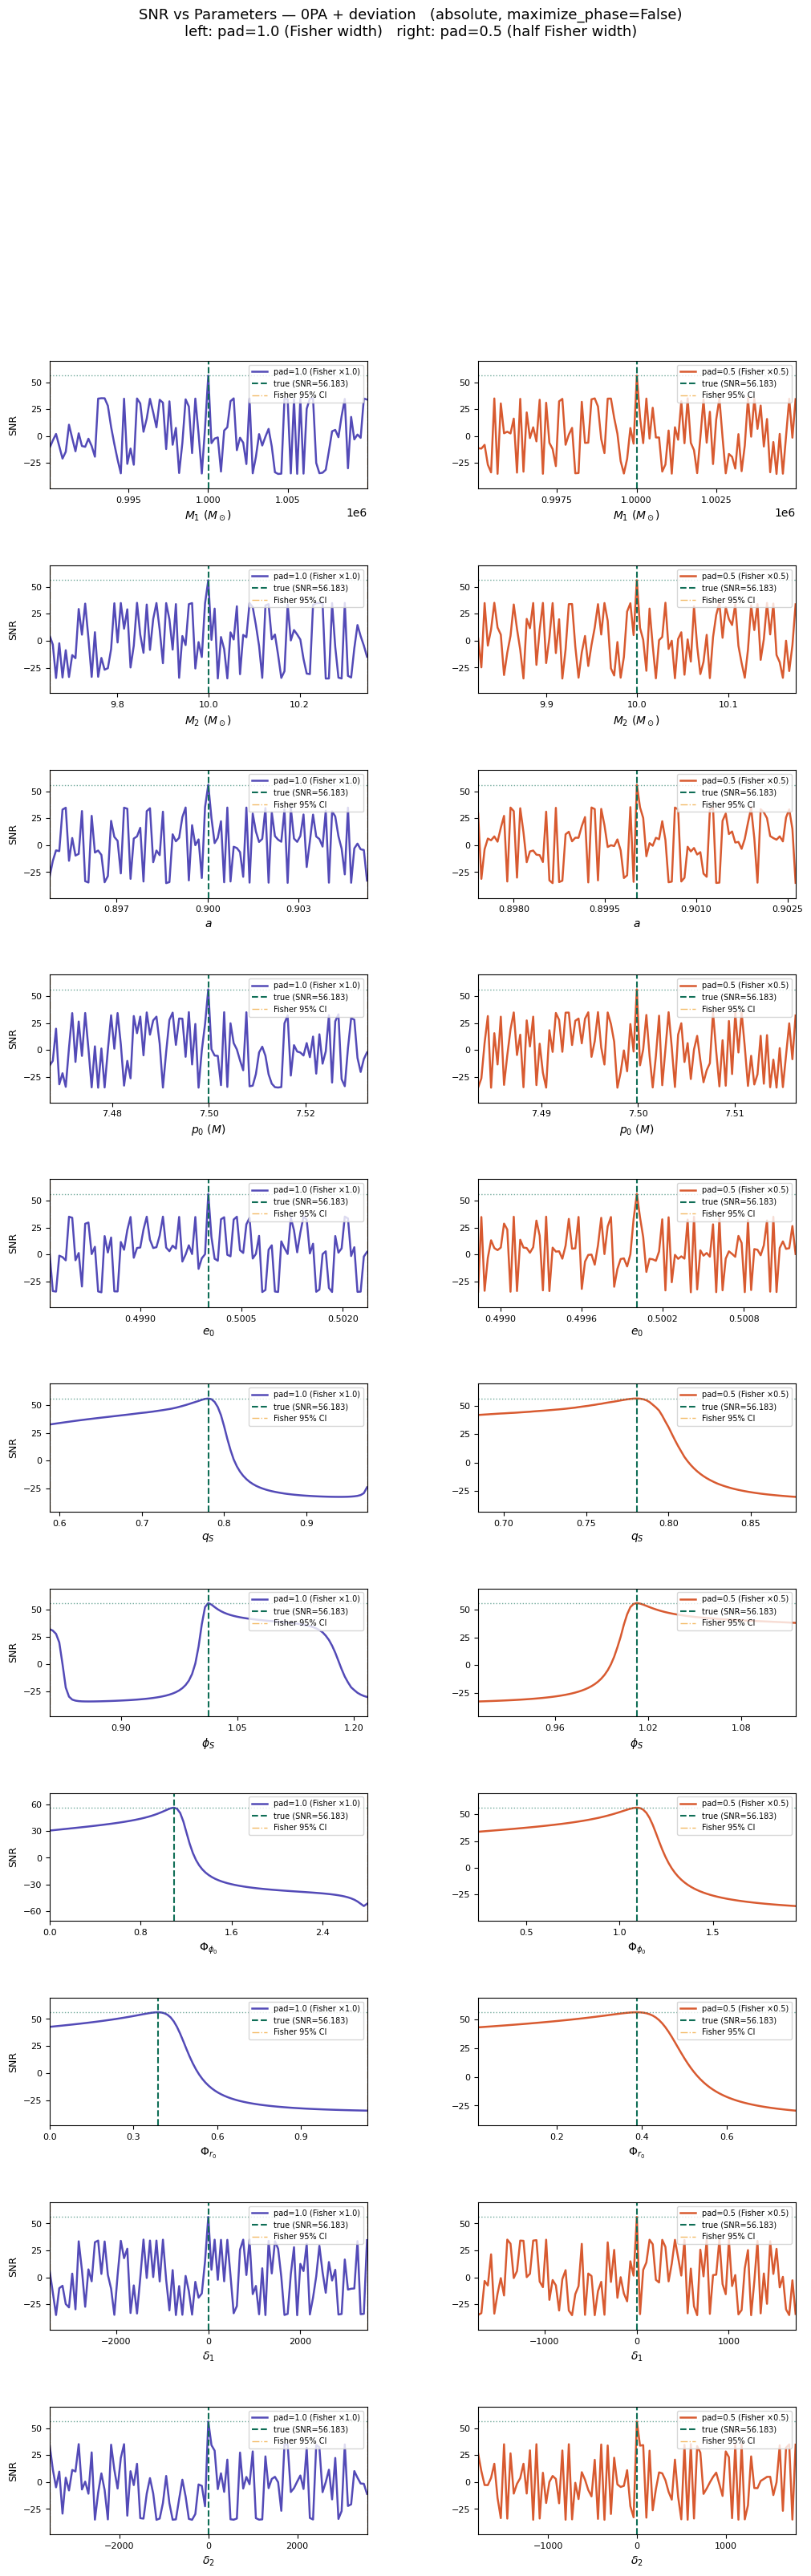

In [4]:
from matplotlib.gridspec import GridSpec

# ── Parameter setup ────────────────────────────────────────────────────────────
param_names_label = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
    r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
    r'$\delta_1$', r'$\delta_2$']

x_best_fit_0PA_dev = [1000008.8232475417, 9.999571552108547, 0.9000238821231858,
                       7.499888382688533, 0.500008994502528, 0.7807665326272081,
                         1.0127748551659106, 1.092204513244811, 0.3880586212252709,
                           2.4076903823412796, -2.5709170953033844]


bounds_0PA_dev = [(np.float64(990056.2866793681), np.float64(1009961.3598157152)),
                  (np.float64(9.651225746662256), np.float64(10.347917357554838)),
                    (np.float64(0.8948030951316116), np.float64(0.9052446691147601)),
                      (np.float64(7.467039216264791), np.float64(7.532737549112275)),
                      (np.float64(0.4976592951836295), np.float64(0.5023586938214265)), 
                      (np.float64(0.5880971759164723), np.float64(0.9734358893379439)), 
                      (np.float64(0.808286354714354), np.float64(1.2172633556174672)), 
                      (np.float64(-0.6051971757225287), np.float64(2.789606202212151)), 
                      (np.float64(-0.36061355135458795), np.float64(1.1367307938051296)), 
                      (np.float64(-3446.923798543717), np.float64(3451.7391793083993)), 
                      (np.float64(-3573.486151948738), np.float64(3568.3443177581316))]

PARAM_BOUNDS = [
    (None, None),
    (None, None),
    (-0.9999, 0.9999),
    (1.0, None),
    (0.0, 0.9999),
    (0.0, np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (None, None),
    (None, None),
]

fixed = {
    'waveform_response': ctx['waveform_response'],
    'PSD':               ctx['PSD_funcs'],
    'dt':                ctx['dt'],
    'T':                 ctx['T'],
    'N_fiducial':        ctx['N_fiducial'],
    'waveform_true_fft': ctx['waveform_true_fft'],
    'xp':                np,
    'delta_f':           ctx['delta_f'],
    'use_gpu':           True,
}

N_PARAMS    = len(x_best_fit_0PA_dev)
N_POINTS    = 100
# pad=1.0 → window = full Fisher width centred on true point
# pad=0.5 → window = half Fisher width (zoomed in)
PAD_FACTORS = [1.0, 0.5]


# ── Grid builder — true point always an exact node ─────────────────────────────
def make_grid(idx, pad, n_points=N_POINTS):
    lo, hi   = bounds_0PA_dev[idx]
    half     = (hi - lo) / 2.0
    true_val = x_best_fit_0PA_dev[idx]

    raw_lo = true_val - pad * half
    raw_hi = true_val + pad * half

    phys_lo, phys_hi = PARAM_BOUNDS[idx]
    if phys_lo is not None:
        raw_lo = max(raw_lo, phys_lo)
    if phys_hi is not None:
        raw_hi = min(raw_hi, phys_hi)

    frac_left = (true_val - raw_lo) / (raw_hi - raw_lo)
    n_left    = max(2, round(n_points * frac_left))
    n_right   = max(2, n_points - n_left + 1)

    left  = np.linspace(raw_lo,   true_val, n_left)
    right = np.linspace(true_val, raw_hi,   n_right)

    return np.concatenate([left, right[1:]])


# ── SNR profile ────────────────────────────────────────────────────────────────
def compute_snr_profile(idx, pad, n_points=N_POINTS):
    grid = make_grid(idx, pad, n_points)
    snr  = np.empty(len(grid))

    theta = list(x_best_fit_0PA_dev)
    for k, x in enumerate(grid):
        theta[idx] = x
        m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_1, dev_2 = theta
        # dev_1/dev_2 updated per iteration so varying them sweeps correctly
        add_kwargs = {'chi2': 0.0, 'evolve_1PA': False, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': dev_1, 'dev_2': dev_2}
        snr[k] = calculate_detection_snr_0pa_vs_1pa(
            m1, m2, a, p0, e0, ctx['Y0'], ctx['dist'], qS, phiS, ctx['qK'], ctx['phiK'],
            Phi_phi0, ctx['Phi_theta0'], Phi_r0, add_kwargs,
            maximize_phase=False,
            **fixed)

    true_idx = np.argmin(np.abs(grid - x_best_fit_0PA_dev[idx]))
    snr_true = snr[true_idx]

    return grid, snr, snr_true


# ── Plotting ───────────────────────────────────────────────────────────────────
PAD_COLORS = ['#534AB7', '#D85A30']
PAD_LABELS = [f'pad={p} (Fisher ×{p})' for p in PAD_FACTORS]

def plot_snr_profiles():
    ncols = len(PAD_FACTORS)   # 2 columns: wide | zoomed
    nrows = N_PARAMS            # 11 rows, one per parameter

    fig = plt.figure(figsize=(6 * ncols, 3.2 * nrows))
    gs  = GridSpec(nrows, ncols, figure=fig, hspace=0.6, wspace=0.35)

    for idx in range(N_PARAMS):
        for col, (pad, color, label) in enumerate(zip(PAD_FACTORS, PAD_COLORS, PAD_LABELS)):
            ax = fig.add_subplot(gs[idx, col])

            grid, snr, snr_true = compute_snr_profile(idx, pad)

            ax.plot(grid, snr, color=color, lw=1.8, label=label)

            # horizontal reference at true-point SNR
            ax.axhline(snr_true, color='#0F6E56', lw=1.0, ls=':', alpha=0.6)

            # vertical true-point marker
            ax.axvline(x_best_fit_0PA_dev[idx], color='#0F6E56',
                       lw=1.5, ls='--', label=f'true (SNR={snr_true:.3f})')

            # Fisher bounds as lines (visible at any zoom level)
            lo, hi = bounds_0PA_dev[idx]
            ax.axvline(lo, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7)
            ax.axvline(hi, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7,
                       label='Fisher 95% CI')

            # x-axis limits follow the grid exactly — different per pad and per panel
            ax.set_xlim(grid[0], grid[-1])

            # y-axis tight around SNR range in this window
            snr_min, snr_max = np.min(snr), np.max(snr)
            margin = (snr_max - snr_min) * 0.15 if snr_max > snr_min else abs(snr_true) * 0.01
            ax.set_ylim(snr_min - margin, snr_max + margin)

            if col == 0:
                ax.set_ylabel(r'SNR', fontsize=9)

            ax.set_xlabel(param_names_label[idx], fontsize=10)
            ax.tick_params(labelsize=8)
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))
            ax.ticklabel_format(style='sci', axis='both', scilimits=(-3, 4), useOffset=True)
            ax.legend(fontsize=7, loc='upper right')

    fig.suptitle('SNR vs Parameters — 0PA + deviation   (absolute, maximize_phase=False)\n'
                 'left: pad=1.0 (Fisher width)   right: pad=0.5 (half Fisher width)',
                 fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    plot_snr_profiles()

/tmp/ipykernel_1534297/3935410500.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


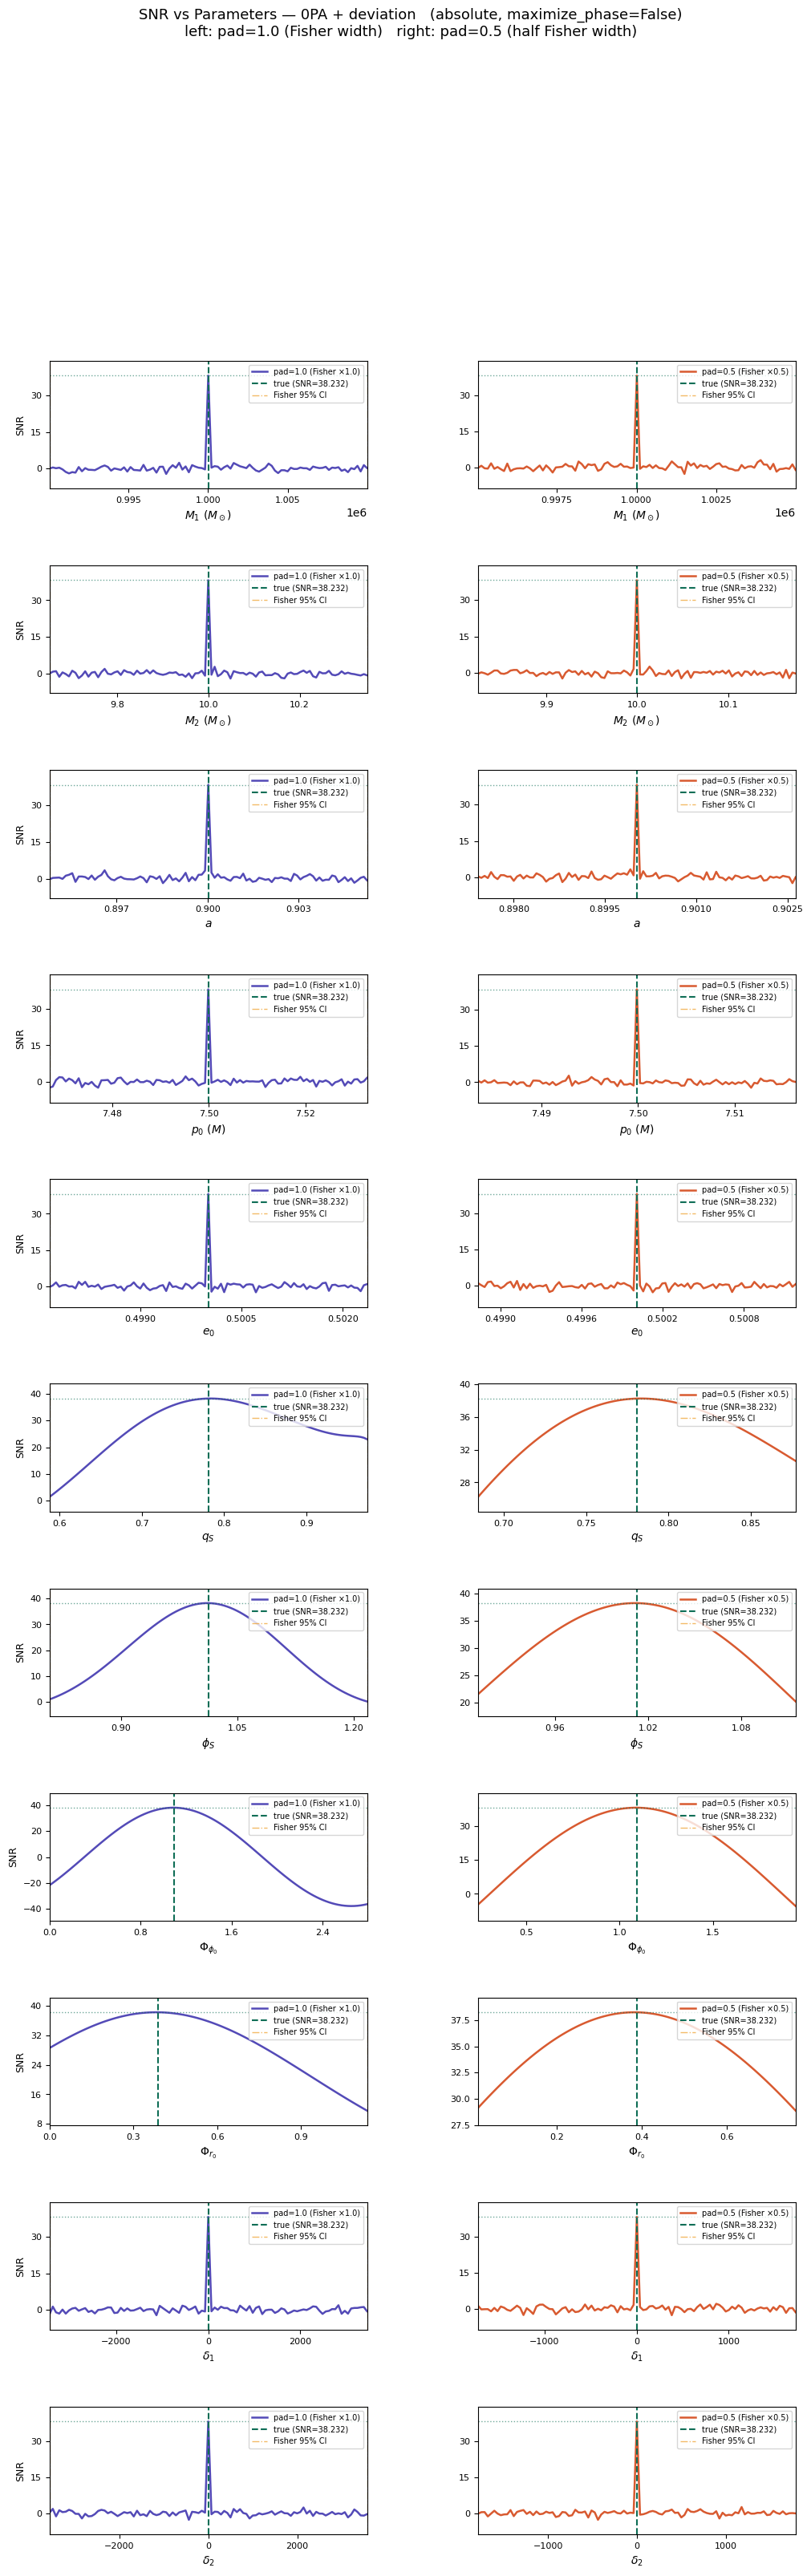

In [8]:
from matplotlib.gridspec import GridSpec

# ── Parameter setup ────────────────────────────────────────────────────────────
param_names_label = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
    r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
    r'$\delta_1$', r'$\delta_2$']

x_best_fit_0PA_dev = [1000008.8232475417, 9.999571552108547, 0.9000238821231858,
                       7.499888382688533, 0.500008994502528, 0.7807665326272081,
                         1.0127748551659106, 1.092204513244811, 0.3880586212252709,
                           2.4076903823412796, -2.5709170953033844]


bounds_0PA_dev = [(np.float64(990056.2866793681), np.float64(1009961.3598157152)),
                  (np.float64(9.651225746662256), np.float64(10.347917357554838)),
                    (np.float64(0.8948030951316116), np.float64(0.9052446691147601)),
                      (np.float64(7.467039216264791), np.float64(7.532737549112275)),
                      (np.float64(0.4976592951836295), np.float64(0.5023586938214265)), 
                      (np.float64(0.5880971759164723), np.float64(0.9734358893379439)), 
                      (np.float64(0.808286354714354), np.float64(1.2172633556174672)), 
                      (np.float64(-0.6051971757225287), np.float64(2.789606202212151)), 
                      (np.float64(-0.36061355135458795), np.float64(1.1367307938051296)), 
                      (np.float64(-3446.923798543717), np.float64(3451.7391793083993)), 
                      (np.float64(-3573.486151948738), np.float64(3568.3443177581316))]

PARAM_BOUNDS = [
    (None, None),
    (None, None),
    (-0.9999, 0.9999),
    (1.0, None),
    (0.0, 0.9999),
    (0.0, np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (None, None),
    (None, None),
]

fixed = {
    'waveform_response': ctx['waveform_response'],
    'PSD':               ctx['PSD_funcs'][0:2],
    'dt':                ctx['dt'],
    'T':                 ctx['T'],
    'N_fiducial':        ctx['N_fiducial'],
    'waveform_true_fft': ctx['waveform_true_fft'][0:2],
    'xp':                np,
    'delta_f':           ctx['delta_f'],
    'use_gpu':           True,
}

N_PARAMS    = len(x_best_fit_0PA_dev)
N_POINTS    = 100
# pad=1.0 → window = full Fisher width centred on true point
# pad=0.5 → window = half Fisher width (zoomed in)
PAD_FACTORS = [1.0, 0.5]


# ── Grid builder — true point always an exact node ─────────────────────────────
def make_grid(idx, pad, n_points=N_POINTS):
    lo, hi   = bounds_0PA_dev[idx]
    half     = (hi - lo) / 2.0
    true_val = x_best_fit_0PA_dev[idx]

    raw_lo = true_val - pad * half
    raw_hi = true_val + pad * half

    phys_lo, phys_hi = PARAM_BOUNDS[idx]
    if phys_lo is not None:
        raw_lo = max(raw_lo, phys_lo)
    if phys_hi is not None:
        raw_hi = min(raw_hi, phys_hi)

    frac_left = (true_val - raw_lo) / (raw_hi - raw_lo)
    n_left    = max(2, round(n_points * frac_left))
    n_right   = max(2, n_points - n_left + 1)

    left  = np.linspace(raw_lo,   true_val, n_left)
    right = np.linspace(true_val, raw_hi,   n_right)

    return np.concatenate([left, right[1:]])


# ── SNR profile ────────────────────────────────────────────────────────────────
def compute_snr_profile(idx, pad, n_points=N_POINTS):
    grid = make_grid(idx, pad, n_points)
    snr  = np.empty(len(grid))

    theta = list(x_best_fit_0PA_dev)
    for k, x in enumerate(grid):
        theta[idx] = x
        m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_1, dev_2 = theta
        # dev_1/dev_2 updated per iteration so varying them sweeps correctly
        add_kwargs = {'chi2': 0.0, 'evolve_1PA': False, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': dev_1, 'dev_2': dev_2}
        snr[k] = calculate_detection_snr_0pa_vs_1pa(
            m1, m2, a, p0, e0, ctx['Y0'], ctx['dist'], qS, phiS, ctx['qK'], ctx['phiK'],
            Phi_phi0, ctx['Phi_theta0'], Phi_r0, add_kwargs,
            maximize_phase=False,
            **fixed)

    true_idx = np.argmin(np.abs(grid - x_best_fit_0PA_dev[idx]))
    snr_true = snr[true_idx]

    return grid, snr, snr_true


# ── Plotting ───────────────────────────────────────────────────────────────────
PAD_COLORS = ['#534AB7', '#D85A30']
PAD_LABELS = [f'pad={p} (Fisher ×{p})' for p in PAD_FACTORS]

def plot_snr_profiles():
    ncols = len(PAD_FACTORS)   # 2 columns: wide | zoomed
    nrows = N_PARAMS            # 11 rows, one per parameter

    fig = plt.figure(figsize=(6 * ncols, 3.2 * nrows))
    gs  = GridSpec(nrows, ncols, figure=fig, hspace=0.6, wspace=0.35)

    for idx in range(N_PARAMS):
        for col, (pad, color, label) in enumerate(zip(PAD_FACTORS, PAD_COLORS, PAD_LABELS)):
            ax = fig.add_subplot(gs[idx, col])

            grid, snr, snr_true = compute_snr_profile(idx, pad)

            ax.plot(grid, snr, color=color, lw=1.8, label=label)

            # horizontal reference at true-point SNR
            ax.axhline(snr_true, color='#0F6E56', lw=1.0, ls=':', alpha=0.6)

            # vertical true-point marker
            ax.axvline(x_best_fit_0PA_dev[idx], color='#0F6E56',
                       lw=1.5, ls='--', label=f'true (SNR={snr_true:.3f})')

            # Fisher bounds as lines (visible at any zoom level)
            lo, hi = bounds_0PA_dev[idx]
            ax.axvline(lo, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7)
            ax.axvline(hi, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7,
                       label='Fisher 95% CI')

            # x-axis limits follow the grid exactly — different per pad and per panel
            ax.set_xlim(grid[0], grid[-1])

            # y-axis tight around SNR range in this window
            snr_min, snr_max = np.min(snr), np.max(snr)
            margin = (snr_max - snr_min) * 0.15 if snr_max > snr_min else abs(snr_true) * 0.01
            ax.set_ylim(snr_min - margin, snr_max + margin)

            if col == 0:
                ax.set_ylabel(r'SNR', fontsize=9)

            ax.set_xlabel(param_names_label[idx], fontsize=10)
            ax.tick_params(labelsize=8)
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))
            ax.ticklabel_format(style='sci', axis='both', scilimits=(-3, 4), useOffset=True)
            ax.legend(fontsize=7, loc='upper right')

    fig.suptitle('SNR vs Parameters — 0PA + deviation   (absolute, maximize_phase=False)\n'
                 'left: pad=1.0 (Fisher width)   right: pad=0.5 (half Fisher width)',
                 fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    plot_snr_profiles()